# MAIE 5101: Programming for Artificial Intelligence
## Programming Assignment 3 - Colorization of Grayscale Images using CNNs

## Description
Welcome to the last assignment! In this assignment, we are going to train a convolutional neural network (CNN) to colorize grayscale images.

The dataset we are going to use is CIFAR-10, and we are going to use an encoder-decoder architecture for this task. Get started by reading the prerequisite knowledge below first!

## Intended Learning Outcomes
Upon completing this assignment, you should be able to:
- Understand the basics of data loading and preprocessing for images;
- Use PyTorch to implement a model from a written description; and
- Train, validate and test neural networks with PyTorch.

## Background Knowledge
### CIEL\*a\*b Color Space
The CIEL\*a\*b color space (or Lab in short) is an alternative representation for colored images. 

Instead of representing images in pairs of red, green and blue colors (like the usual RGB colors), we represent images as three components: the lightness or luminescence (L), and the chroma (which are the *a and *b components). This allows us to separate an image into a grayscale version (by only retaining the L part) and a colored version (one with all three parts).

In this assignment, we will be using the Lab color space extensively. The input to our model would be the L channel (which is the grayscale image), and the model will be tasked to predict the corresponding *a and *b components.

### The Encoder-Decoder Architecture
As mentioned above, our model takes in grayscale images and outputs the corresponding color for each pixel of the images (i.e. 1x32x32 to 2x32x32). This task can be solved by using an encoder-decoder architecture.

The encoder-decoder architecture is separated into two parts: an encoder and a decoder. An encoder encodes the input into a smaller, more compact representation, and the decoder transforms this representation back into a full-sized output.

We will be using a modified version of this architecture in the assignment to colorize our images.

### Data Augmentation
While typical models work well for images of the same orientation, user data can often be slightly rotated or out of shape. To improve the robustness of our model, we can use data augmentation to randomly rotate / flip some of the data we have.

## Dataset
Our dataset is the well-known **CIFAR-10** dataset. It consists of 60,000 32x32 images from 10 classes.

Since this is a well-known dataset, PyTorch provides built-in ways for us to load the data!

## Libraries Required
- matplotlib
- numpy
- scikit-image
- pytorch
- torchvision

Please only use the libraries already imported in the skeleton.

## Installing and Importing Libraries
We will import the libraries you need here.

In [1]:
# For autoreloading files
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt

import colorization as pa3
import models as pa3_models

In [3]:
torch.manual_seed(5101) # For reproducibility

The following cell checks if CUDA is available. You are advised to find a device with CUDA capabilities (such as Nvidia GPUs) for this assignment or use Google Colab; otherwise, training might be slow.

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"The device used is: {device}")

The device used is: cuda


## Task 1: Data Augmentation
Before we can load any data, we first have to complete the function `augment_transform` in `colorization.py` to augment our training dataset.

You can check the [official documentation for `torchvision`](https://docs.pytorch.org/vision/main/transforms.html) for more information.

After you are done with the function, execute the cell below to load the CIFAR-10 data. Feel free to change the location of where the dataset is stored if you wish.

In [5]:
train_set, test_set = pa3.load_cifar_10("./dataset")

100.0%


Extracting ./dataset\cifar-10-python.tar.gz to ./dataset


d:\Desktop\ASSN\Semester 2\PAI\ASSN3\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


Let's sample some data from our training set. You should see some different images each time you run these cells.

In [6]:
# These are the textual labels for our data.
cifar_key_labels = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

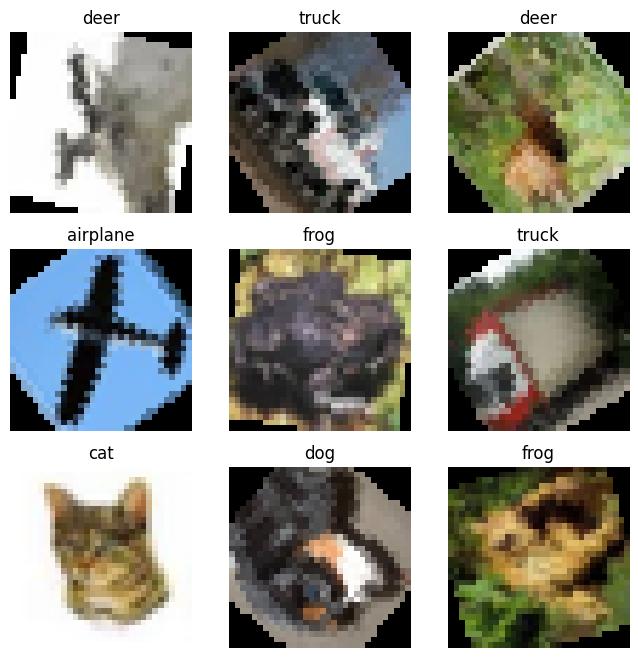

In [9]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    img = img.permute(1, 2, 0)
    figure.add_subplot(rows, cols, i)
    plt.title(cifar_key_labels[label])
    plt.axis("off")
    plt.imshow(img.squeeze())
plt.show()

## Task 2: RGB to Lab
So far, our dataset objects store images in the RGB format. However, as mentioned, we need to transform them into the Lab format for our neural network.

Complete the functions `rgb_to_lab_tensor` and `lab_to_rgb_tensor` in `colorization.py` to transform a tensor of RGB images into Lab images.

Note that the passed in tensor can contain multiple images (you will see why when we do batching in a minute). You may consider the inputs to be in `(N, 3, H, W)`, where:
- `N` is the number of images in this batch;
- `3` is the number of channels (i.e. 3 because we have R, G, B and L, *a, *b channels respectively)
- `H` is the height (i.e. 32)
- `W` is the width (i.e. 32 as well).

Test your code with the cell below to see if the RGB to Lab conversion works both ways.

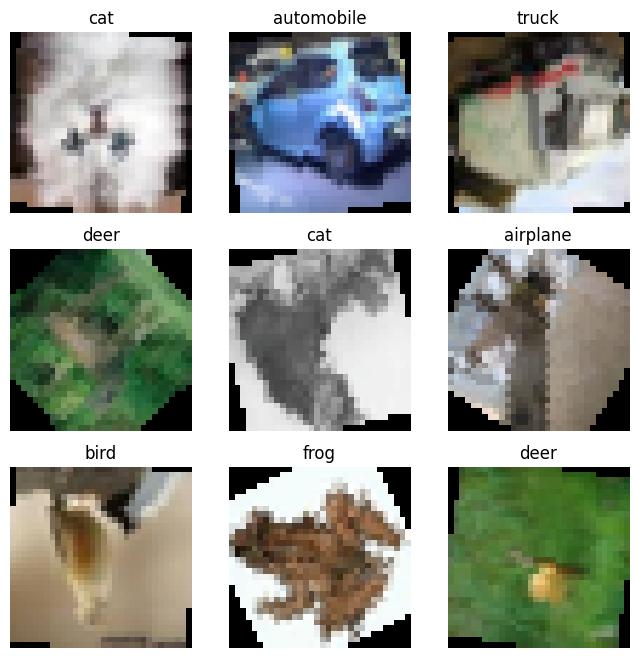

In [10]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    # Image is in (3, 32, 32) now; we should make this (1, 3, 32, 32) using unsqueeze
    img = img.unsqueeze(0)
    lab_tensor = pa3.rgb_to_lab_tensor(img) # You can print this out for debugging if needed
    rgb_tensor = pa3.lab_to_rgb_tensor(lab_tensor) # Same as above
    img = rgb_tensor.squeeze(0).permute(1, 2, 0) # Drop extra dim & permute to (32, 32, 3) for matplotlib
    
    figure.add_subplot(rows, cols, i)
    plt.title(cifar_key_labels[label])
    plt.axis("off")
    plt.imshow(img.squeeze())
plt.show()

## Task 3: Data Loaders
Now that we have our `rgb_to_lab_tensor` and `lab_to_rgb_tensor` functions, we can proceed to the next step and divide our data into training, validation and testing sets.

Complete the function `get_data_loaders` to create the train, validation and testing data loaders. While we can't test this directly, you will be able to test it during the next task.

Feel free to tweak the batch size and train-validation split for tuning performance if you wish.

In [11]:
train_loader, val_loader, test_loader = pa3.get_data_loaders(train_set, test_set, 64, 0.8)

## Task 4: Model Architecture
With our new data loaders, we are now finally ready to design our encoder-decoder network.

Complete the definition of the `ColorizationCnn` class in `models.py` with the architecture in the documentation.

You should initialize the layers in `__init__`, and complete `forward` such that the model correctly processes images.

In [12]:
model = pa3_models.ColorizationCnn()

Run the code below to check your implementation. The solution implementation stores each layer as its own separate instance variable; you do not need to follow this convention.

In [13]:
print(model)

ColorizationCnn(
  (enc1_conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1_conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2_conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2_conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bot_conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bot_conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec1_conv): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec1_up): Upsample(scale_factor=2.0, mode='bilinear')
  (dec2_conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec2_up): Upsample(scale_factor=2.0, mode='bilinear')
  (out_conv1): Conv2d(64, 32

## Task 5: Model Training
Our model is now ready to be trained. However, you still have to write the training loop!

Since this is a regression task, we will be using the following settings:
- `MSELoss`
- `Adam` optimizer

We will be training the model by first passing in training images from the training data loader for training, then using the validation data to check the performance of the model. We will save the most performant model under `best_model.pth`.

Please see the documentation of `train_model` in `colorization.py` for more details. Feel free to tweak the learning rate for fine-tuning.

Run the next cell to train the model once you're done. It is possible that the first run takes quite a bit of time to print the first message; please be patient and only stop the cell from executing once you've waited some time.

In [14]:
train_loss, val_loss = pa3.train_model(model, train_loader, val_loader)

Epoch  1/20 | Train Loss: 0.00972 | Val Loss: 0.00946
  -> Saved new best model
Epoch  2/20 | Train Loss: 0.00950 | Val Loss: 0.00940
  -> Saved new best model
Epoch  3/20 | Train Loss: 0.00935 | Val Loss: 0.00938
  -> Saved new best model
Epoch  4/20 | Train Loss: 0.00900 | Val Loss: 0.00876
  -> Saved new best model
Epoch  5/20 | Train Loss: 0.00886 | Val Loss: 0.00875
  -> Saved new best model
Epoch  6/20 | Train Loss: 0.00877 | Val Loss: 0.00859
  -> Saved new best model
Epoch  7/20 | Train Loss: 0.00872 | Val Loss: 0.00862
Epoch  8/20 | Train Loss: 0.00868 | Val Loss: 0.00853
  -> Saved new best model
Epoch  9/20 | Train Loss: 0.00862 | Val Loss: 0.00849
  -> Saved new best model
Epoch 10/20 | Train Loss: 0.00861 | Val Loss: 0.00849
Epoch 11/20 | Train Loss: 0.00857 | Val Loss: 0.00845
  -> Saved new best model
Epoch 12/20 | Train Loss: 0.00855 | Val Loss: 0.00839
  -> Saved new best model
Epoch 13/20 | Train Loss: 0.00855 | Val Loss: 0.00835
  -> Saved new best model
Epoch 14/20 

Let's plot the training and validation losses:

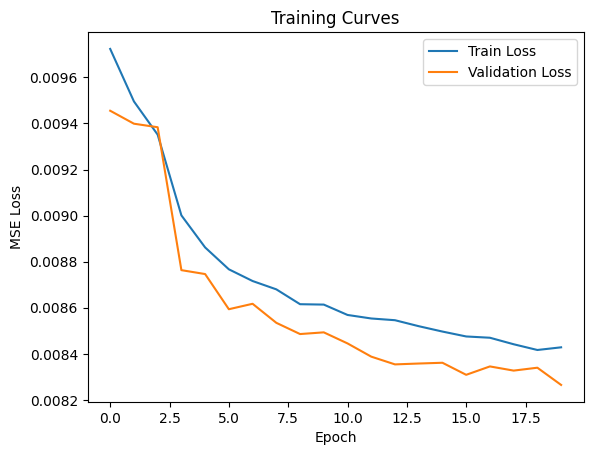

In [15]:
plt.figure()
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training Curves')
plt.savefig('loss_curves.png')
plt.show()

We can also display a few images from our training:

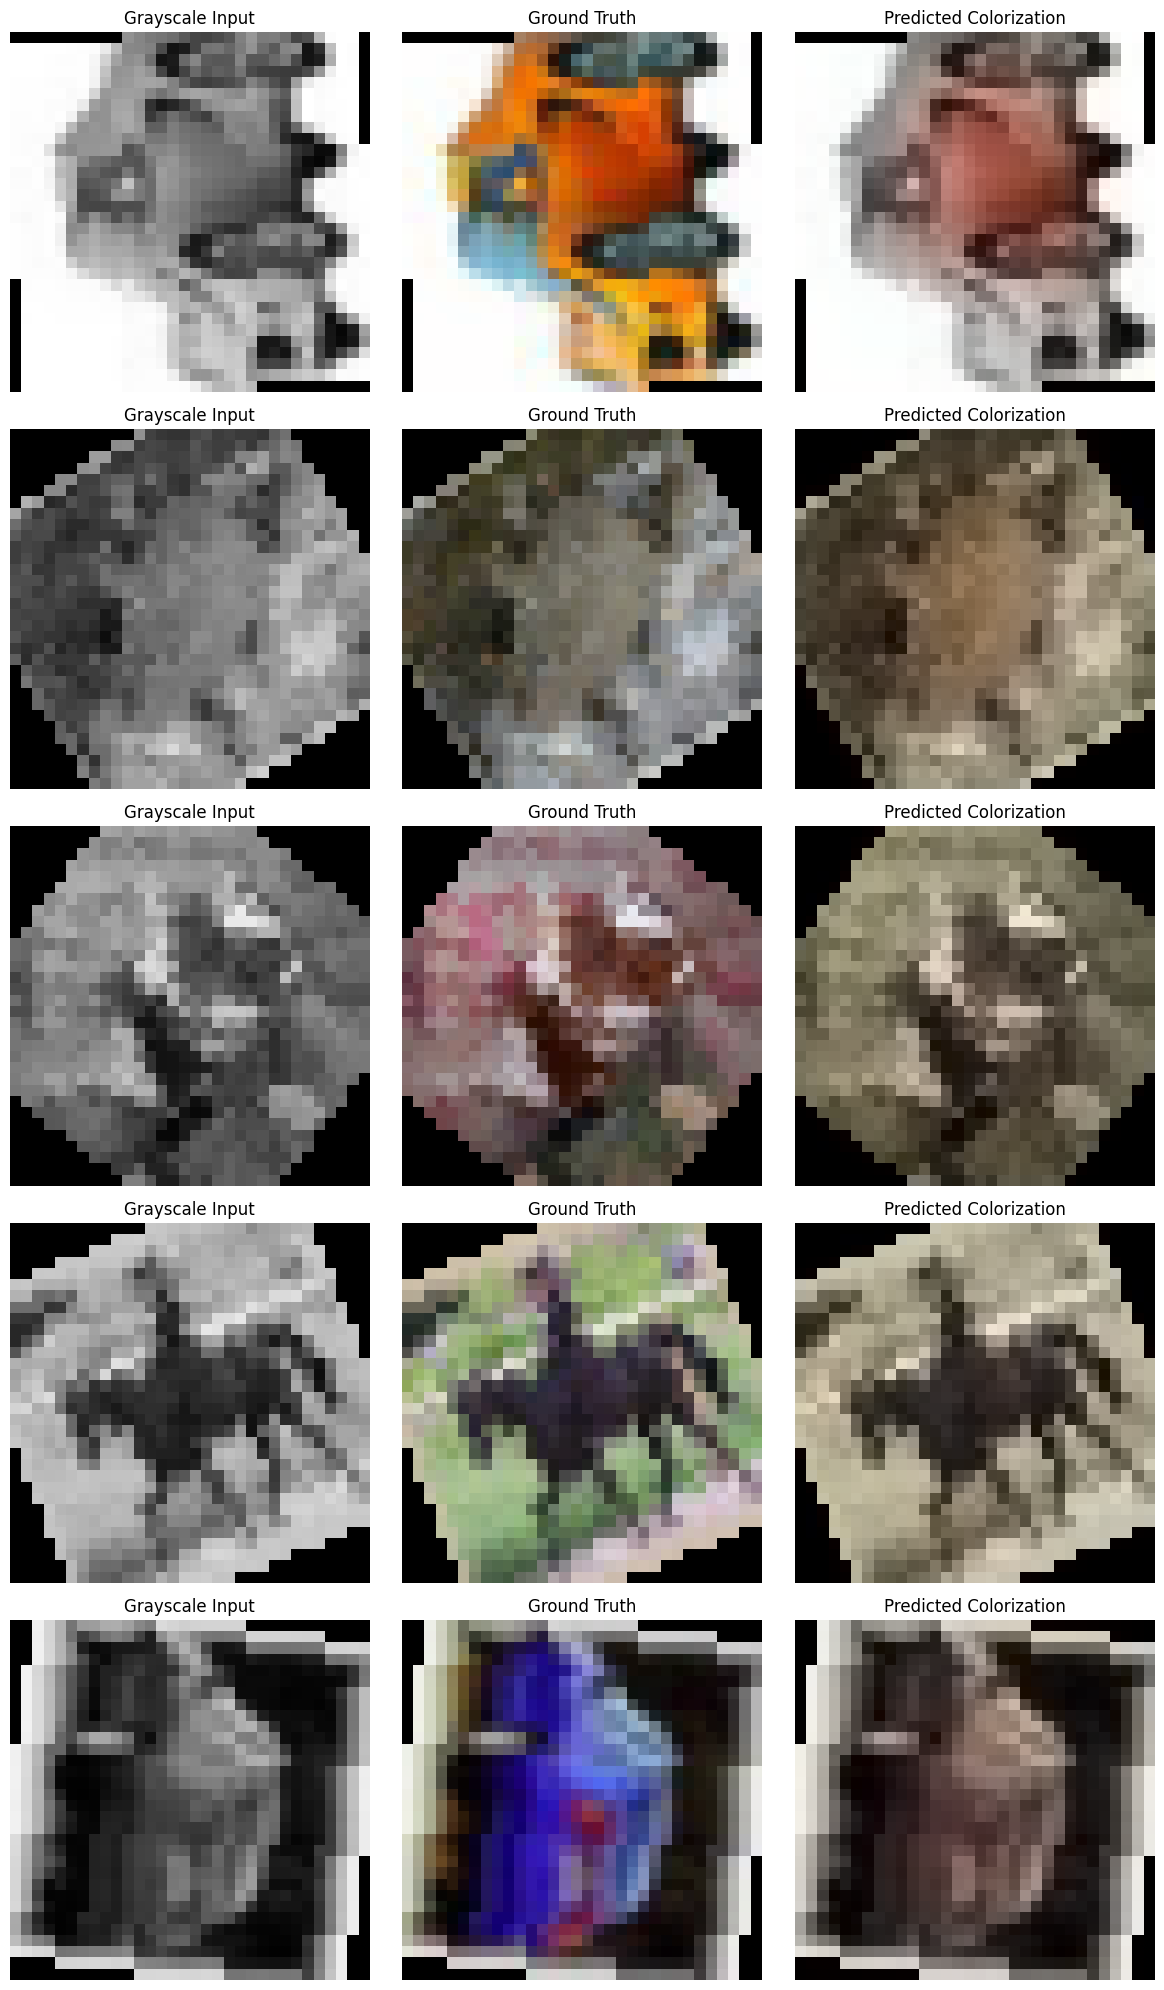

In [18]:
pa3.visualize_predictions(model, val_loader)

## Task 6: Model Testing
To evaluate our model, we use two different metrics:
- The Peak Signal-to-Noise Ratio (PSNR). The higher the PSNR, the closer our colorization is to the original in absolute terms.
- The Structural Similarity (SSIM). The higher the SSIM, the closer our colorization is in human perception terms.

Complete the function `compute_metrics` in `colorization.py` to evaluate our model using the test set.

Run the cell below to compute the metrics once you're done.

In [19]:
psnr, ssim = pa3.compute_metrics(model, test_loader)
print(f"The PSNR is: {psnr}")
print(f"The SSIM is: {ssim}")

The PSNR is: 24.74417885878406
The SSIM is: 0.9340468645095825


# Submission and Grading
You only need to submit `models.py` and `colorization.py` as a ZIP to Canvas. The notebook need not be submitted. The deadline for this assignment is **May 11, 2359 HKT**.